# Z24 PDT cleaning

This notebook cleans the Progressive Damage Test (PDT) data. The condition directory (01--17) is stored as the class label. It keeps measurement type, setup, and channel metadata.

Run the full export cell to process all PDT recordings. The smoke test is optional and commented out.


In [ ]:
from pathlib import Path
import sys
import json
from datetime import datetime

search_paths = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in search_paths if (p / 'prepare_pdt.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the shm project.')
sys.path.insert(0, str(ROOT))
from prepare_pdt import clean_pdt, SCENARIO_LABELS

ARCHIVE = ROOT / 'raw_data' / 'sources-Z24-004.zip'
print('Project:', ROOT)
print('Archive exists:', ARCHIVE.exists())


The next cell processes AVT and FVT separately. Each measurement gets its own timestamped folder under `processed/avt` or `processed/fvt`. Windows-safe names use `dd-mm-yyyy_HH-mm-ss`; the report stores `dd/mm/yyyy hh:mm:ss`.


In [ ]:
MAX_CONDITIONS = None
MAX_SETUPS = None
MEASUREMENTS = ("avt", "fvt")
reports = {}

for measurement in MEASUREMENTS:
    run_time = datetime.now()
    run_name = run_time.strftime("%d/%m/%Y %H:%M:%S")
    folder_name = run_time.strftime(f"{measurement}_%d-%m-%Y_%H-%M-%S")
    OUTPUT = ROOT / "processed" / measurement / folder_name
    report = clean_pdt(ARCHIVE, OUTPUT, measurement=measurement,
                       max_conditions=MAX_CONDITIONS, max_setups=MAX_SETUPS)
    report["run_name"] = run_name
    report["output_folder"] = str(OUTPUT)
    (OUTPUT / "report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
    reports[measurement] = report
    print(measurement.upper(), "run:", run_name, "segments:", report["segments"])


## Labels

`condition_id` is the directory number and `label = condition_id - 1`. The descriptive names below come from the official Z24 progressive-damage scenario table. Conditions 1, 2, and 8 are reference/transition conditions, so do not silently collapse them into a healthy class without defining that rule in the paper.


In [ ]:
for condition, name in SCENARIO_LABELS.items():
    print(f'{condition:02d} -> label {condition - 1:02d}: {name}')


## Visual checks

These charts show how many recordings exist for each condition and what a sensor time series looks like. They read only one CSV for the signal plots, so they do not reload the full dataset.


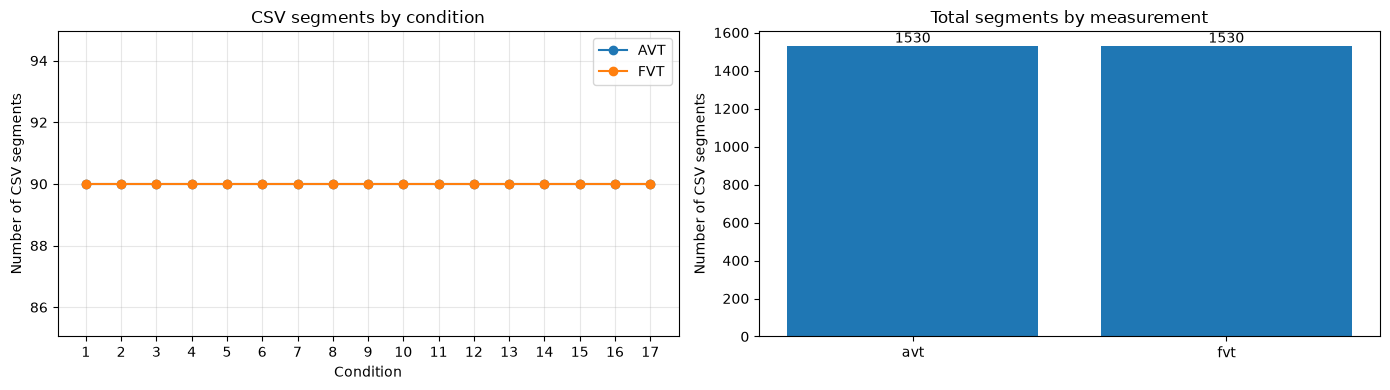

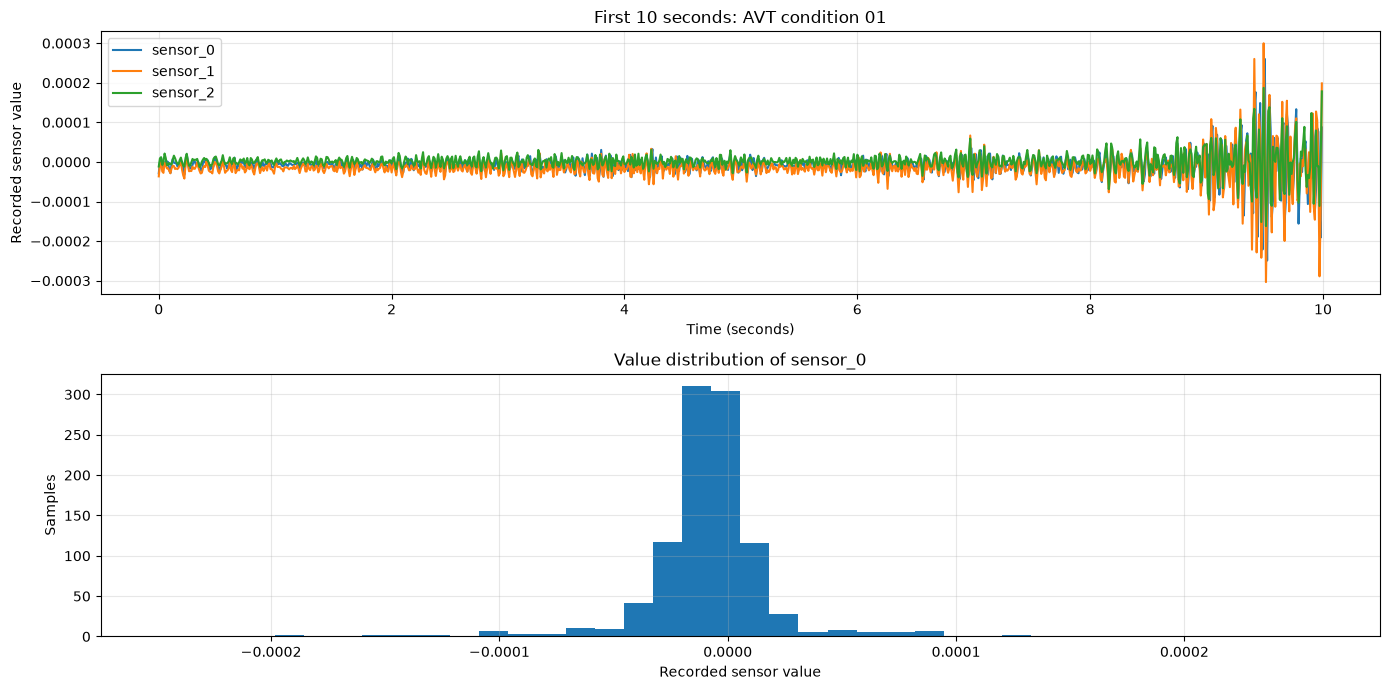

In [10]:
from collections import Counter
import csv
import matplotlib.pyplot as plt
import numpy as np

RUNS = {}
MANIFESTS = {}
for measurement in ("avt", "fvt"):
    candidates = [p for p in (ROOT / "processed" / measurement).glob("*") if (p / "manifest.json").exists()]
    if not candidates:
        continue
    RUNS[measurement] = max(candidates, key=lambda p: p.stat().st_mtime)
    MANIFESTS[measurement] = json.loads((RUNS[measurement] / "manifest.json").read_text())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for measurement, records in MANIFESTS.items():
    counts = Counter(r["condition_id"] for r in records)
    conditions = sorted(counts)
    axes[0].plot(conditions, [counts[c] for c in conditions], marker="o", label=measurement.upper())
axes[0].set_title("CSV segments by condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Number of CSV segments")
axes[0].set_xticks(range(1, 18))
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].bar(list(MANIFESTS), [len(v) for v in MANIFESTS.values()])
axes[1].set_title("Total segments by measurement")
axes[1].set_ylabel("Number of CSV segments")
for i, value in enumerate([len(v) for v in MANIFESTS.values()]):
    axes[1].text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

measurement = "avt" if "avt" in RUNS else next(iter(RUNS))
row = MANIFESTS[measurement][0]
csv_path = RUNS[measurement] / Path(row["file"])
values = np.loadtxt(csv_path, delimiter=",", skiprows=1, max_rows=1000, usecols=range(row["channels"] + 1))
time = values[:, 0] / 100.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for sensor in range(min(3, row["channels"])):
    axes[0].plot(time, values[:, sensor + 1], label=f"sensor_{sensor}")
condition_id = row["condition_id"]
axes[0].set_title(f"First 10 seconds: {measurement.upper()} condition {condition_id:02d}")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Recorded sensor value")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].hist(values[:, 1], bins=40)
axes[1].set_title("Value distribution of sensor_0")
axes[1].set_xlabel("Recorded sensor value")
axes[1].set_ylabel("Samples")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
